# Continuous Ranked Probability Score (CRPS)

A proper scoring rule for evaluating probabilistic forecasts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

## Definition

CRPS measures the distance between a predicted cumulative distribution function (CDF) and the observed outcome.

For a predicted CDF $F(x)$ and an observation $y$:

$$\text{CRPS} = \int_{-\infty}^{\infty} [F(x) - \mathbb{1}(x \geq y)]^2 dx$$

where $\mathbb{1}(x \geq y)$ is the Heaviside step function (0 if $x < y$, 1 if $x \geq y$).

**Key properties:**
- Lower CRPS = better forecast
- CRPS = 0: perfect prediction
- Units: same as the observed variable (mm for precipitation)

CRPS rewards both **accuracy** (peaked at the observation) AND **calibration** (appropriate uncertainty).

## Example 1: Perfect Prediction

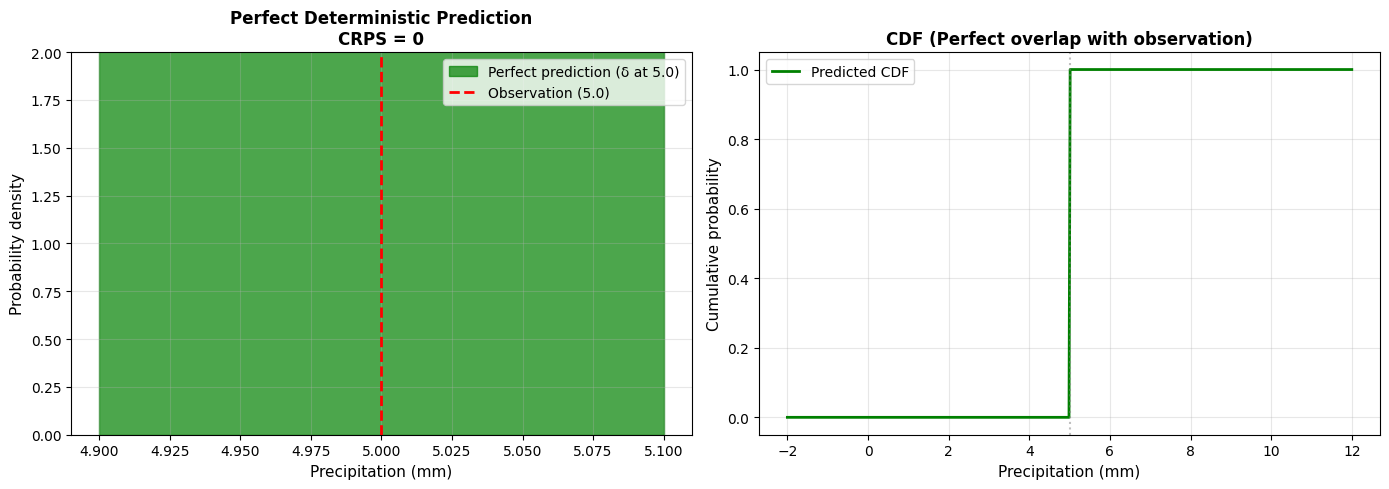

Case: Perfect deterministic prediction
  Observation: 5.0 mm
  Prediction: δ(x - 5.0)
  CRPS: 0.000 mm



In [2]:
y_obs = 5.0
x = np.linspace(-2, 12, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF (delta function)
ax1.fill_between([y_obs - 0.1, y_obs + 0.1], 0, 10, alpha=0.7, color="green", label="Perfect prediction (δ at 5.0)")
ax1.axvline(y_obs, color="red", linestyle="--", linewidth=2, label="Observation (5.0)")
ax1.set_xlabel("Precipitation (mm)", fontsize=11)
ax1.set_ylabel("Probability density", fontsize=11)
ax1.set_title("Perfect Deterministic Prediction\nCRPS = 0", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_ylim(0, 2)
ax1.grid(alpha=0.3)

# Right: CDF (step function)
cdf_perfect = np.where(x >= y_obs, 1.0, 0.0)
ax2.plot(x, cdf_perfect, "g-", linewidth=2, label="Predicted CDF")
ax2.axvline(y_obs, color="gray", linestyle=":", alpha=0.5)
ax2.set_xlabel("Precipitation (mm)", fontsize=11)
ax2.set_ylabel("Cumulative probability", fontsize=11)
ax2.set_title("CDF (Perfect overlap with observation)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("Case: Perfect deterministic prediction")
print(f"  Observation: {y_obs:.1f} mm")
print(f"  Prediction: δ(x - {y_obs})")
print(f"  CRPS: 0.000 mm")
print()

## Example 2: Overconfident (Wrong but Certain)

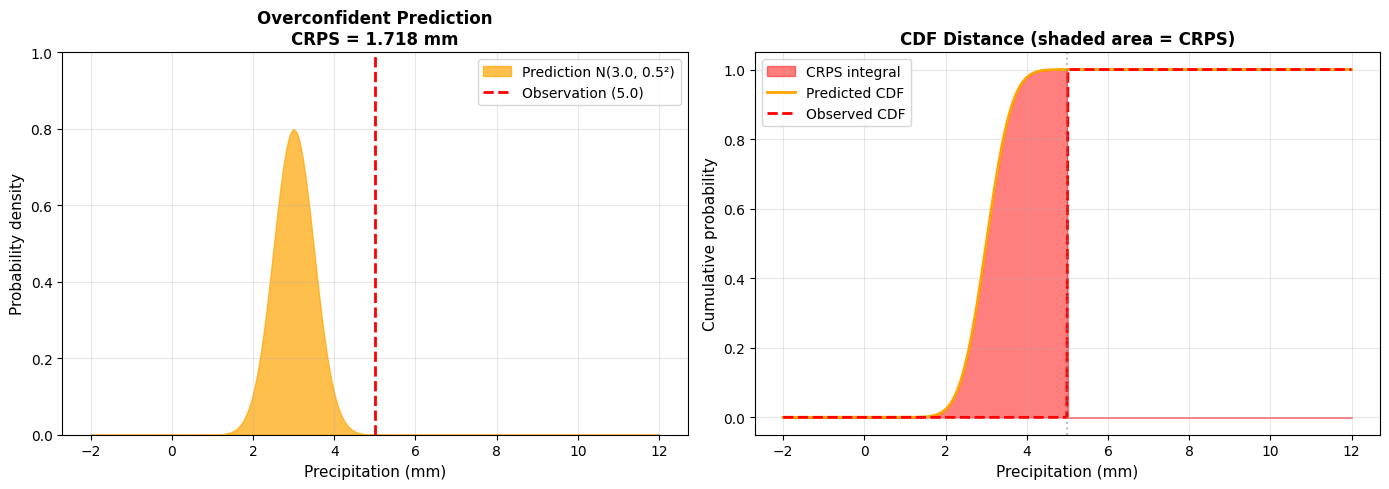

Case: Overconfident (wrong direction, too narrow)
  Observation: 5.0 mm
  Prediction: N(μ=3.0, σ=0.5)
  CRPS: 1.718 mm  ← HIGH (bad)
  → Large CRPS because prediction is wrong and overconfident



In [3]:
y_obs = 5.0
pred_mean = 3.0
pred_std = 0.5

x = np.linspace(-2, 12, 500)
pdf = norm.pdf(x, pred_mean, pred_std)
cdf = norm.cdf(x, pred_mean, pred_std)
cdf_obs_step = np.where(x >= y_obs, 1.0, 0.0)

crps = pred_std * (((y_obs - pred_mean) / pred_std) * (2 * norm.cdf((y_obs - pred_mean) / pred_std) - 1) + 2 * norm.pdf((y_obs - pred_mean) / pred_std) - 1 / np.sqrt(np.pi))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF
ax1.fill_between(x, 0, pdf, alpha=0.7, color="orange", label=f"Prediction N({pred_mean}, {pred_std}²)")
ax1.axvline(y_obs, color="red", linestyle="--", linewidth=2, label=f"Observation ({y_obs})")
ax1.set_xlabel("Precipitation (mm)", fontsize=11)
ax1.set_ylabel("Probability density", fontsize=11)
ax1.set_title(f"Overconfident Prediction\nCRPS = {crps:.3f} mm", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

# Right: CDF with CRPS area
ax2.fill_between(x, 0, np.abs(cdf - cdf_obs_step), alpha=0.5, color="red", label="CRPS integral")
ax2.plot(x, cdf, "orange", linewidth=2, label="Predicted CDF")
ax2.plot(x, cdf_obs_step, "r--", linewidth=2, label="Observed CDF")
ax2.axvline(y_obs, color="gray", linestyle=":", alpha=0.5)
ax2.set_xlabel("Precipitation (mm)", fontsize=11)
ax2.set_ylabel("Cumulative probability", fontsize=11)
ax2.set_title("CDF Distance (shaded area = CRPS)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("Case: Overconfident (wrong direction, too narrow)")
print(f"  Observation: {y_obs:.1f} mm")
print(f"  Prediction: N(μ={pred_mean}, σ={pred_std})")
print(f"  CRPS: {crps:.3f} mm  ← HIGH (bad)")
print(f"  → Large CRPS because prediction is wrong and overconfident")
print()

## Example 3: Well-Calibrated (Correct & Honest)

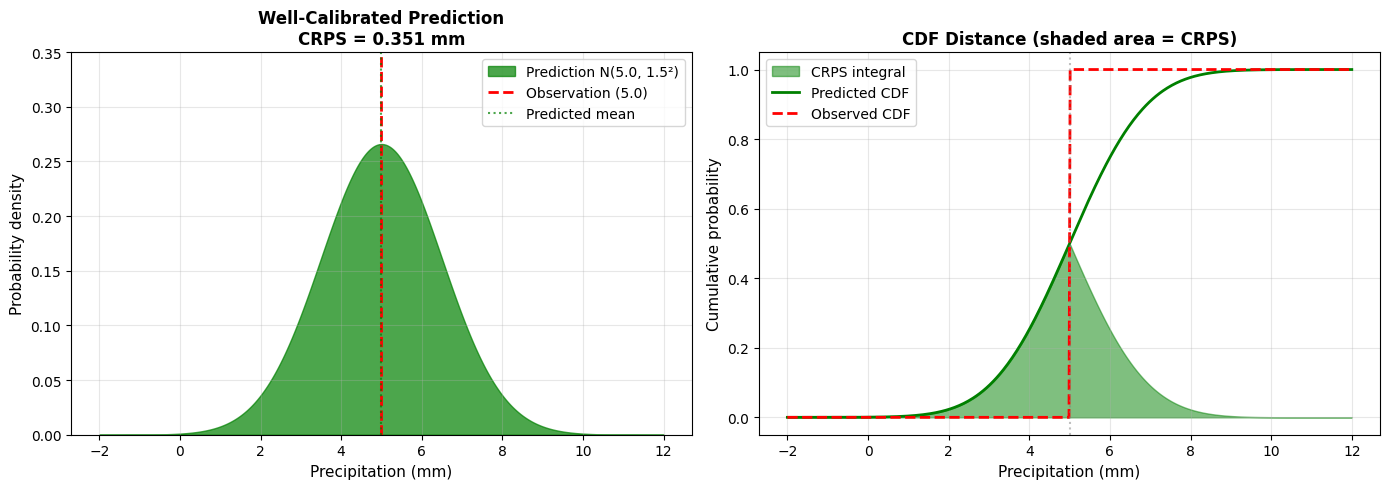

Case: Well-calibrated (correct AND honest about uncertainty)
  Observation: 5.0 mm
  Prediction: N(μ=5.0, σ=1.5)
  CRPS: 0.351 mm  ← LOW (good)
  → Low CRPS: accurate point estimate + appropriate uncertainty



In [4]:
y_obs = 5.0
pred_mean = 5.0
pred_std = 1.5

x = np.linspace(-2, 12, 500)
pdf = norm.pdf(x, pred_mean, pred_std)
cdf = norm.cdf(x, pred_mean, pred_std)
cdf_obs_step = np.where(x >= y_obs, 1.0, 0.0)

crps = pred_std * (((y_obs - pred_mean) / pred_std) * (2 * norm.cdf((y_obs - pred_mean) / pred_std) - 1) + 2 * norm.pdf((y_obs - pred_mean) / pred_std) - 1 / np.sqrt(np.pi))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF
ax1.fill_between(x, 0, pdf, alpha=0.7, color="green", label=f"Prediction N({pred_mean}, {pred_std}²)")
ax1.axvline(y_obs, color="red", linestyle="--", linewidth=2, label=f"Observation ({y_obs})")
ax1.axvline(pred_mean, color="green", linestyle=":", linewidth=1.5, alpha=0.7, label="Predicted mean")
ax1.set_xlabel("Precipitation (mm)", fontsize=11)
ax1.set_ylabel("Probability density", fontsize=11)
ax1.set_title(f"Well-Calibrated Prediction\nCRPS = {crps:.3f} mm", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_ylim(0, 0.35)
ax1.grid(alpha=0.3)

# Right: CDF
ax2.fill_between(x, 0, np.abs(cdf - cdf_obs_step), alpha=0.5, color="green", label="CRPS integral")
ax2.plot(x, cdf, "g-", linewidth=2, label="Predicted CDF")
ax2.plot(x, cdf_obs_step, "r--", linewidth=2, label="Observed CDF")
ax2.axvline(y_obs, color="gray", linestyle=":", alpha=0.5)
ax2.set_xlabel("Precipitation (mm)", fontsize=11)
ax2.set_ylabel("Cumulative probability", fontsize=11)
ax2.set_title("CDF Distance (shaded area = CRPS)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("Case: Well-calibrated (correct AND honest about uncertainty)")
print(f"  Observation: {y_obs:.1f} mm")
print(f"  Prediction: N(μ={pred_mean}, σ={pred_std})")
print(f"  CRPS: {crps:.3f} mm  ← LOW (good)")
print(f"  → Low CRPS: accurate point estimate + appropriate uncertainty")
print()

## Example 4: Underconfident (Correct but Too Uncertain)

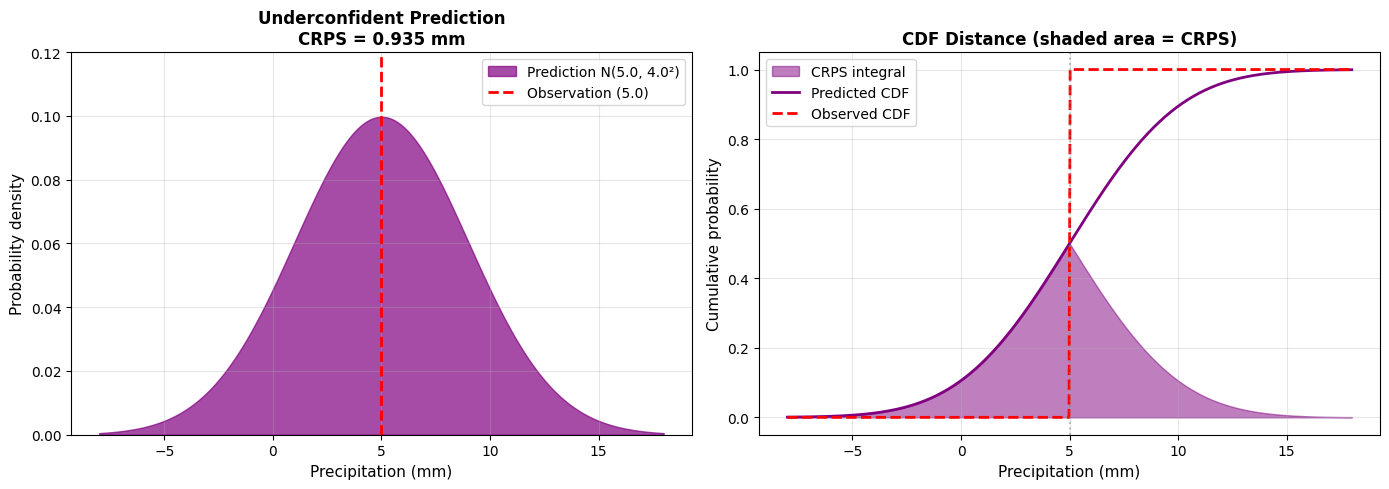

Case: Underconfident (correct mean, too wide distribution)
  Observation: 5.0 mm
  Prediction: N(μ=5.0, σ=4.0)
  CRPS: 0.935 mm  ← MODERATE (acceptable)
  → Moderate CRPS: accurate but spreads probability too wide



In [5]:
y_obs = 5.0
pred_mean = 5.0
pred_std = 4.0

x = np.linspace(-8, 18, 500)
pdf = norm.pdf(x, pred_mean, pred_std)
cdf = norm.cdf(x, pred_mean, pred_std)
cdf_obs_step = np.where(x >= y_obs, 1.0, 0.0)

crps = pred_std * (((y_obs - pred_mean) / pred_std) * (2 * norm.cdf((y_obs - pred_mean) / pred_std) - 1) + 2 * norm.pdf((y_obs - pred_mean) / pred_std) - 1 / np.sqrt(np.pi))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF
ax1.fill_between(x, 0, pdf, alpha=0.7, color="purple", label=f"Prediction N({pred_mean}, {pred_std}²)")
ax1.axvline(y_obs, color="red", linestyle="--", linewidth=2, label=f"Observation ({y_obs})")
ax1.set_xlabel("Precipitation (mm)", fontsize=11)
ax1.set_ylabel("Probability density", fontsize=11)
ax1.set_title(f"Underconfident Prediction\nCRPS = {crps:.3f} mm", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_ylim(0, 0.12)
ax1.grid(alpha=0.3)

# Right: CDF
ax2.fill_between(x, 0, np.abs(cdf - cdf_obs_step), alpha=0.5, color="purple", label="CRPS integral")
ax2.plot(x, cdf, "purple", linewidth=2, label="Predicted CDF")
ax2.plot(x, cdf_obs_step, "r--", linewidth=2, label="Observed CDF")
ax2.axvline(y_obs, color="gray", linestyle=":", alpha=0.5)
ax2.set_xlabel("Precipitation (mm)", fontsize=11)
ax2.set_ylabel("Cumulative probability", fontsize=11)
ax2.set_title("CDF Distance (shaded area = CRPS)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("Case: Underconfident (correct mean, too wide distribution)")
print(f"  Observation: {y_obs:.1f} mm")
print(f"  Prediction: N(μ={pred_mean}, σ={pred_std})")
print(f"  CRPS: {crps:.3f} mm  ← MODERATE (acceptable)")
print(f"  → Moderate CRPS: accurate but spreads probability too wide")
print()

## Summary: CRPS Ranking

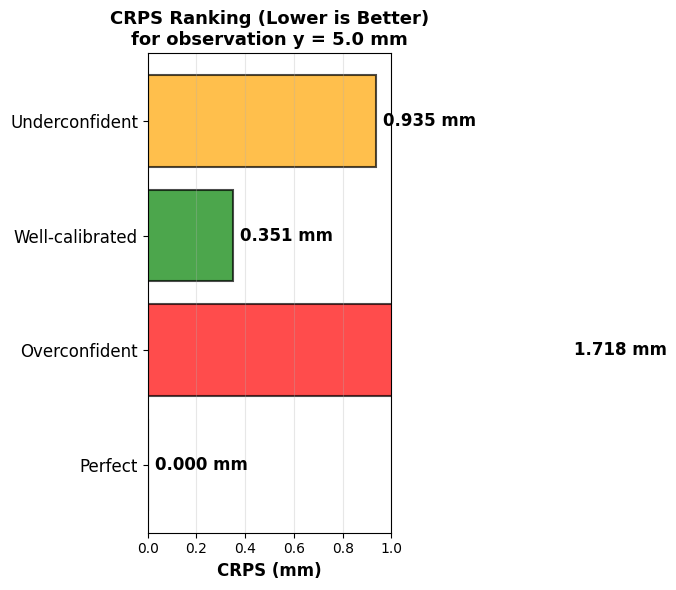

CRPS Ranking (best to worst):
Rank   Case                      μ      σ     CRPS
--------------------------------------------------
1      Perfect                 5.0   0.01    0.000
2      Overconfident           3.0   0.50    1.718
3      Well-calibrated         5.0   1.50    0.351
4      Underconfident          5.0   4.00    0.935


In [6]:
# Compute all CRPS values for comparison
cases = [
    ("Perfect", 5.0, 0.01),
    ("Overconfident", 3.0, 0.5),
    ("Well-calibrated", 5.0, 1.5),
    ("Underconfident", 5.0, 4.0),
]

crps_values = []
for name, mu, sigma in cases:
    if sigma < 0.1:
        crps = 0.0
    else:
        y = 5.0
        z = (y - mu) / sigma
        crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    crps_values.append(crps)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["darkgreen", "red", "green", "orange"]
y_pos = np.arange(len(cases))

bars = ax.barh(y_pos, crps_values, color=colors, alpha=0.7, edgecolor="black", linewidth=1.5)

for i, (bar, val) in enumerate(zip(bars, crps_values)):
    ax.text(val + 0.03, bar.get_y() + bar.get_height()/2, f"{val:.3f} mm", 
            va="center", fontsize=12, fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels([c[0] for c in cases], fontsize=12)
ax.set_xlabel("CRPS (mm)", fontsize=12, fontweight="bold")
ax.set_title("CRPS Ranking (Lower is Better)\nfor observation y = 5.0 mm", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.0)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("CRPS Ranking (best to worst):")
print(f"{'Rank':<6} {'Case':<20} {'μ':>6} {'σ':>6} {'CRPS':>8}")
print("-" * 50)
for i, (name, mu, sigma, crps) in enumerate(zip([c[0] for c in cases], [c[1] for c in cases], [c[2] for c in cases], crps_values), 1):
    print(f"{i:<6} {name:<20} {mu:>6.1f} {sigma:>6.2f} {crps:>8.3f}")

## Why CRPS for Kriging?

### The Problem with MAE/RMSE

Traditional metrics (MAE, RMSE) only evaluate the point forecast:
$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |\hat{z}_i - y_i|$$

They **ignore uncertainty** entirely. A forecast that says "5 mm ± 0.1 mm" (very confident) and one that says "5 mm ± 10 mm" (very uncertain) both score the same MAE if both estimated 5 mm.

### CRPS Advantage

In ordinary kriging, we produce:
- **Point estimate**: kriging mean $\hat{z}(x_0)$
- **Uncertainty**: kriging variance $\sigma_k^2(x_0)$

Together these define a **Gaussian predictive distribution**:
$$F(z | x_0) = \Phi\left(\frac{z - \hat{z}(x_0)}{\sigma_k(x_0)}\right)$$

CRPS evaluates the **entire distribution** against observations:
1. **Penalizes bias** — if $\hat{z}$ is far from the true value
2. **Penalizes overconfidence** — if $\sigma_k$ is too small  
3. **Rewards calibration** — if $\sigma_k$ matches actual error spread

| Metric | Penalizes Bias | Penalizes Uncertainty | Units |
|--------|:-:|:-:|---|
| MAE | ✓ | ✗ | mm |
| RMSE | ✓ | ✗ | mm |
| **CRPS** | **✓** | **✓** | **mm** |

CRPS is a **proper scoring rule**: it cannot be gamed by artificially broadening the forecast distribution.

## Implementation in Kriging

### With Back-Transformation

In kriging with transforms (e.g., normal-score):

1. Kriging produces: $(\mu_z, \sigma_z^2)$ in transformed space
2. Back-transform via Monte Carlo:
   - Draw $M = 500$ samples: $z^{(m)} \sim N(\mu_z, \sigma_z^2)$
   - Apply inverse transform: $x^{(m)} = g^{-1}(z^{(m)})$ → precipitation in mm
   - Empirical CDF: $\hat{F}(x) = \frac{1}{M} \sum_{m=1}^{M} \mathbb{1}(x^{(m)} \leq x)$
3. Compute CRPS: $\text{CRPS} = \int [\hat{F}(x) - \mathbb{1}(x \geq y_\text{obs})]^2 dx$

This allows evaluation in **physical units** (mm) while accounting for the full uncertainty structure and any nonlinearities in back-transformation.

### Average CRPS

For an entire dataset:
$$\overline{\text{CRPS}} = \frac{1}{N} \sum_{i=1}^{N} \text{CRPS}_i$$

In the thesis:
- **Best combo (none + exponential)**: CRPS = 0.7981 mm (20.4 million LOO predictions)
- **Normal-score + exponential**: CRPS = 0.8538 mm (slightly worse calibration)
- **Log + exponential**: CRPS = 0.8573 mm (log transform spreads uncertainty too wide)